In [ ]:
from __future__ import annotations

import tempfile
from dataclasses import dataclass
from pathlib import Path

import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix



HANDWRITING_PATCH_SIZE = 64
HANDWRITING_PATCH_STRIDE = 32
HANDWRITING_PATCHES_PER_IMAGE = 150
HANDWRITING_THRESHOLD = 0.7

HANDWRITING_MODEL_PATH = "..\\src\\ocr_preprocessing_models\\handwriting_model_rf.joblib"
HANDWRITING_MODEL_XGB_PATH = "..\\src\\ocr_preprocessing_models\\handwriting_model_xgb.joblib"

IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}

In [ ]:
@dataclass
class HandwritingRemovalModel:
    classifier: RandomForestClassifier
    patchSize: int
    stride: int
    threshold: float



In [ ]:
def collectImagePaths(folderPath):
    folder = Path(folderPath)
    return sorted(
        path for path in folder.rglob('*')
        if path.suffix.lower() in IMAGE_EXTENSIONS
    )



def loadGrayImage(imagePath):
    image = cv2.imread(str(imagePath), cv2.IMREAD_COLOR)

    if image is None:
        raise FileNotFoundError(str(imagePath))

    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


def buildHogDescriptor(patchSize):
    blockSize = (patchSize // 2, patchSize // 2)

    blockStride = (patchSize // 4, patchSize // 4)

    cellSize = (patchSize // 4, patchSize // 4)

    return cv2.HOGDescriptor(
        (patchSize, patchSize),
        blockSize,
        blockStride,
        cellSize,
        9,
    )


def padImage(image, patchSize):
    height, width = image.shape[:2]

    padBottom = max(0, patchSize - height)

    padRight = max(0, patchSize - width)

    if padBottom == 0 and padRight == 0:
        return image

    return cv2.copyMakeBorder(
        image,
        0,
        padBottom,
        0,
        padRight,
        cv2.BORDER_REFLECT,
    )               


def windowPositions(length, windowSize, stride):
    if length <= windowSize:           
        return [0]

    positions = list(range(0, length - windowSize + 1, stride))

    last =  length-windowSize

    if positions[-1] != last:
        
        positions.append(last)

    return positions

In [99]:
def extractLBPFeatures(image, radius=2, points=16):

    lbp = local_binary_pattern(
        image,
        P=points,
        R=radius,
        method='uniform',
    )

    histogram, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, points + 3),
        range=(0, points + 2),
    )

    histogram = histogram.astype(np.float32)

    histogram /= (histogram.sum() + 1e-6)

    return histogram

In [ ]:

def extractPatchFeatures(patch, hogDescriptor):

    resized = cv2.resize(
        patch,
        hogDescriptor.winSize,
        interpolation=cv2.INTER_AREA,
    )

    floatPatch = resized.astype(np.float32) / 255.0


    hogFeatures = hogDescriptor.compute(resized).reshape(-1)


    inkMask = cv2.adaptiveThreshold(
        resized,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        17,
        11,
    )


    edgeMask = cv2.Canny(resized, 40, 120)


    sobelX = cv2.Sobel(floatPatch, cv2.CV_32F, 1, 0, ksize=3)

    sobelY = cv2.Sobel(floatPatch, cv2.CV_32F, 0, 1, ksize=3)

    gradient = np.hypot(sobelX, sobelY)

    histogram = cv2.calcHist(
        [resized],
        [0],
        None,
        [16],
        [0, 256],
    ).flatten()


    histogram = histogram / max(histogram.sum(), 1.0)

    histogram = np.clip(histogram, 1e-8, 1.0)


    components = cv2.connectedComponents(inkMask)[0] - 1


    foregroundRatio = float(np.mean(inkMask > 0))

    edgeDensity = float(np.mean(edgeMask > 0))

    horizontalProjection = inkMask.sum(axis=1).astype(np.float32)
    
    verticalProjection = inkMask.sum(axis=0).astype(np.float32)

    scalarFeatures = np.array(
        [
            float(floatPatch.mean()),
            float(floatPatch.std()),
            float(np.median(floatPatch)),
            float(np.percentile(floatPatch, 10)),
            float(np.percentile(floatPatch, 90)),
            foregroundRatio,
            edgeDensity,
            float(cv2.Laplacian(floatPatch, cv2.CV_32F).var()),
            float(gradient.mean()),
            float(gradient.std()),
            float(components),
            float(horizontalProjection.var()),
            float(verticalProjection.var()),
        ],
        dtype=np.float32,
    )

    lbpFeatures = extractLBPFeatures(resized)

    return np.concatenate([
        hogFeatures.astype(np.float32),
        lbpFeatures.astype(np.float32),
        scalarFeatures,
        histogram.astype(np.float32),
    ])

In [101]:
def sampleTrainingPatches(
    image,
    label,
    patchSize,
    patchesPerImage,
    hogDescriptor,
    randomState,
):
    rng = np.random.default_rng(randomState)

    padded = padImage(image, patchSize)

    height, width = padded.shape[:2]

    maxY = height - patchSize
    maxX = width - patchSize

    features = []
    labels = []

    for _ in range(patchesPerImage):

        y = int(rng.integers(0, maxY + 1))
        x = int(rng.integers(0, maxX + 1))

        patch = padded[y:y + patchSize, x:x + patchSize]

        features.append(
            extractPatchFeatures(patch, hogDescriptor)
        )

        labels.append(label)

    return features, labels


def buildTrainingSet(
    handwrittenPaths,
    cleanPaths,
    patchSize,
    patchesPerImage,
    randomState,
):

    hogDescriptor = buildHogDescriptor(patchSize)

    features = []
    labels = []

    print(f"Sampling {patchesPerImage} patches from {len(handwrittenPaths)} handwritten images")

    for index, imagePath in enumerate(handwrittenPaths):

        print(f"  handwritten [{index + 1}/{len(handwrittenPaths)}]: {imagePath.name}")

        image = loadGrayImage(imagePath)

        sampledFeatures, sampledLabels = sampleTrainingPatches(
            image=image,
            label=1,
            patchSize=patchSize,
            patchesPerImage=patchesPerImage,
            hogDescriptor=hogDescriptor,
            randomState=randomState + index,
        )

        features.extend(sampledFeatures)
        labels.extend(sampledLabels)

        print(f"    collected {len(sampledFeatures)} patches")

    print(f"Sampling {patchesPerImage} patches from {len(cleanPaths)} clean images")

    for index, imagePath in enumerate(cleanPaths):

        print(f"  clean [{index + 1}/{len(cleanPaths)}]: {imagePath.name}")

        image = loadGrayImage(imagePath)

        sampledFeatures, sampledLabels = sampleTrainingPatches(
            image=image,
            label=0,
            patchSize=patchSize,
            patchesPerImage=patchesPerImage,
            hogDescriptor=hogDescriptor,
            randomState=randomState + 10000 + index,
        )

        features.extend(sampledFeatures)
        labels.extend(sampledLabels)

        print(f"    collected {len(sampledFeatures)} patches")

    return (
        np.asarray(features, dtype=np.float32),
        np.asarray(labels, dtype=np.int32),
    )

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
 )
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

import time


def trainAndCompareModels(
    handwrittenDir,
    cleanDir,
    patchSize=HANDWRITING_PATCH_SIZE,
    stride=HANDWRITING_PATCH_STRIDE,
    patchesPerImage=HANDWRITING_PATCHES_PER_IMAGE,
    randomState=42,
 ):

    print("Starting handwriting training run")

    handwrittenPaths = collectImagePaths(handwrittenDir)
    cleanPaths = collectImagePaths(cleanDir)

    print(f"Handwritten images: {len(handwrittenPaths)}")
    print(f"Clean images: {len(cleanPaths)}")

    if len(handwrittenPaths) == 0 or len(cleanPaths) == 0:
        raise ValueError(
            f"Expected images in both folders, got handwritten={len(handwrittenPaths)} and clean={len(cleanPaths)}. "
            f"Check handwrittenDir={handwrittenDir} and cleanDir={cleanDir}"
        )

    print("Building feature set")
    features, labels = buildTrainingSet(
        handwrittenPaths,
        cleanPaths,
        patchSize,
        patchesPerImage,
        randomState,
    )

    print("\nDataset Shape")
    print(features.shape)

 

    print("Feature set ready")

    print("Splitting train and test sets")
    X_train, X_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.2,
        stratify=labels,
        random_state=randomState,
    )

    print("\nTrain samples:", len(X_train))
    print("Test samples:", len(X_test))

    
    print("Training RandomForest on CPU")
    rf = RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=randomState,
  
    )

    start = time.time()

    rf.fit(X_train, y_train)

    print("RandomForest training complete")
    rf_train_time = time.time() - start

    start = time.time()

    rf_predictions = rf.predict(X_test)

    print("RandomForest evaluation complete")
    rf_inference_time = time.time() - start

  
    print("Training XGBoost on GPU")
    xgb = XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        device='cuda',
        random_state=randomState,
    )

    start = time.time()

    xgb.fit(X_train, y_train)

    print("XGBoost training complete")
    xgb_train_time = time.time() - start

    start = time.time()

    xgb_predictions = xgb.predict(X_test)

    print("XGBoost evaluation complete")
    xgb_inference_time = time.time() - start

    print("\n==============================")
    print(" RANDOM FOREST RESULTS ")
    print("==============================")

    print("\nAccuracy:",
          accuracy_score(y_test, rf_predictions))

    print("F1 Score:",
          f1_score(y_test, rf_predictions))

    print("\nClassification Report")
    print(classification_report(y_test, rf_predictions))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, rf_predictions))

    print("\nTraining Time:", rf_train_time)
    print("Inference Time:", rf_inference_time)

    
    print("\n==============================")
    print(" XGBOOST RESULTS ")
    print("==============================")

    print("\nAccuracy:",
          accuracy_score(y_test, xgb_predictions))

    print("F1 Score:",
          f1_score(y_test, xgb_predictions))

    print("\nClassification Report")
    print(classification_report(y_test, xgb_predictions))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, xgb_predictions))

    print("\nTraining Time:", xgb_train_time)
    print("Inference Time:", xgb_inference_time)

    model_obj = HandwritingRemovalModel(
        classifier=rf,
        patchSize=patchSize,
        stride=stride,
        threshold=HANDWRITING_THRESHOLD,
    )

    joblib.dump(model_obj, HANDWRITING_MODEL_PATH)
    print(f"Saved HandwritingRemovalModel to {HANDWRITING_MODEL_PATH}")
    
    model_obj_xgb = HandwritingRemovalModel(
        classifier=xgb,
        patchSize=patchSize,
        stride=stride,
        threshold=HANDWRITING_THRESHOLD,
    )

    joblib.dump(model_obj_xgb, HANDWRITING_MODEL_XGB_PATH)
    print(f"Saved HandwritingRemovalModel (XGB) to {HANDWRITING_MODEL_XGB_PATH}")

    print("Training run finished")

    return rf, xgb

In [ ]:
def loadHandwritingRemovalModel(modelPath):
    model = joblib.load(modelPath)

    if isinstance(model, HandwritingRemovalModel):
        return model
    
    
    if isinstance(model, dict):
        return HandwritingRemovalModel(**model)

    if hasattr(model, 'predict_proba'):
        return HandwritingRemovalModel(
            classifier=model,
            patchSize=HANDWRITING_PATCH_SIZE,
            stride=HANDWRITING_PATCH_STRIDE,
            threshold=HANDWRITING_THRESHOLD,
        )

    raise TypeError(f"Unsupported model object loaded from {modelPath}: {type(model)}")



def predictHandwritingScoreMap(image, model):

    grayscale = (
        image
        if image.ndim == 2
        else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    )

    padded = padImage(grayscale, model.patchSize)

    hogDescriptor = buildHogDescriptor(model.patchSize)

    height, width = padded.shape[:2]

    yPositions = windowPositions(
        height,
        model.patchSize,
        model.stride,
    )

    xPositions = windowPositions(
        width,
        model.patchSize,
        model.stride,
    )

    classes = getattr(model.classifier, 'classes_', None)
    if classes is None or 1 not in classes:
        raise ValueError(f"Classifier classes do not contain positive label 1: {classes}")

    positiveIndex = int(np.where(classes == 1)[0][0])

    patchPositions = []
    patchFeatures = []

    for y in yPositions:
        for x in xPositions:
            patch = padded[
                y:y + model.patchSize,
                x:x + model.patchSize,
            ]
            patchPositions.append((y, x))
            patchFeatures.append(extractPatchFeatures(patch, hogDescriptor))

    featureMatrix = np.asarray(patchFeatures, dtype=np.float32)
    scores = model.classifier.predict_proba(featureMatrix)[:, positiveIndex]

    scoreMap = np.zeros((height, width), dtype=np.float32)
    weightMap = np.zeros((height, width), dtype=np.float32)

    for (y, x), score in zip(patchPositions, scores):
        score = float(score)
        scoreMap[
            y:y + model.patchSize,
            x:x + model.patchSize,
        ] += score

        weightMap[
            y:y + model.patchSize,
            x:x + model.patchSize,
        ] += 1.0

    scoreMap = scoreMap / np.maximum(weightMap, 1.0)

    scoreMap = cv2.GaussianBlur(
        scoreMap,
        (0, 0),
        sigmaX=max(1, model.patchSize // 4),
    )

    return scoreMap[:grayscale.shape[0], :grayscale.shape[1]]



def buildHandwritingMask(scoreMap, threshold):

    mask = (scoreMap >= threshold).astype(np.uint8) * 255

    componentCount, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    cleanedMask = np.zeros_like(mask)

    for label in range(1, componentCount):
        if stats[label, cv2.CC_STAT_AREA] >= 8:
            cleanedMask[labels == label] = 255

    return cleanedMask

In [104]:
def showResults(original, scoreMap, mask, cleaned):

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 4, 1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("Score Map")
    plt.imshow(scoreMap, cmap='hot')
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Cleaned")
    plt.imshow(cv2.cvtColor(cleaned, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:


handwritten_dir = "C:\\Users\\ziada\Downloads\\handwritten"
clean_dir = "C:\\Users\\ziada\\Downloads\\nothandwritten"

rf_model, xgb_model = trainAndCompareModels(
    handwrittenDir=handwritten_dir,
    cleanDir=clean_dir,
)

<>:3: DeprecationWarning: invalid escape sequence '\D'
<>:3: DeprecationWarning: invalid escape sequence '\D'
C:\Users\ziada\AppData\Local\Temp\ipykernel_21896\3210758384.py:3: DeprecationWarning: invalid escape sequence '\D'
  handwritten_dir = "C:\\Users\\ziada\Downloads\\handwritten"


Starting handwriting training run
Handwritten images: 200
Clean images: 200
Building feature set
Sampling 150 patches from 200 handwritten images
  handwritten [1/200]: 522849632+-9633.tif
    collected 150 patches
  handwritten [2/200]: 522849637+-9637.tif
    collected 150 patches
  handwritten [3/200]: 522849726+-9727.tif
    collected 150 patches
  handwritten [4/200]: 522849889+-9890.tif
    collected 150 patches
  handwritten [5/200]: 522849941+-9941.tif
    collected 150 patches
  handwritten [6/200]: 522853254+-3255.tif
    collected 150 patches
  handwritten [7/200]: 522853297+-3301.tif
    collected 150 patches
  handwritten [8/200]: 522854772+-4772.tif
    collected 150 patches
  handwritten [9/200]: 522854845+-4845.tif
    collected 150 patches
  handwritten [10/200]: 522856003+-6004.tif
    collected 150 patches
  handwritten [11/200]: 522856161+-6163.tif
    collected 150 patches
  handwritten [12/200]: 522856203+-6204.tif
    collected 150 patches
  handwritten [13/200]:

d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle

RandomForest training complete


d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle

RandomForest evaluation complete
Training XGBoost on GPU
XGBoost training complete
XGBoost evaluation complete

 RANDOM FOREST RESULTS 

Accuracy: 0.7779166666666667
F1 Score: 0.7364778008503906

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.94      0.81      6000
           1       0.91      0.62      0.74      6000

    accuracy                           0.78     12000
   macro avg       0.81      0.78      0.77     12000
weighted avg       0.81      0.78      0.77     12000


Confusion Matrix
[[5611  389]
 [2276 3724]]

Training Time: 87.21651005744934
Inference Time: 0.557396650314331

 XGBOOST RESULTS 

Accuracy: 0.7821666666666667
F1 Score: 0.7412393585428628

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.94      0.81      6000
           1       0.91      0.62      0.74      6000

    accuracy                           0.78     12000
   macro avg       0.81

d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle

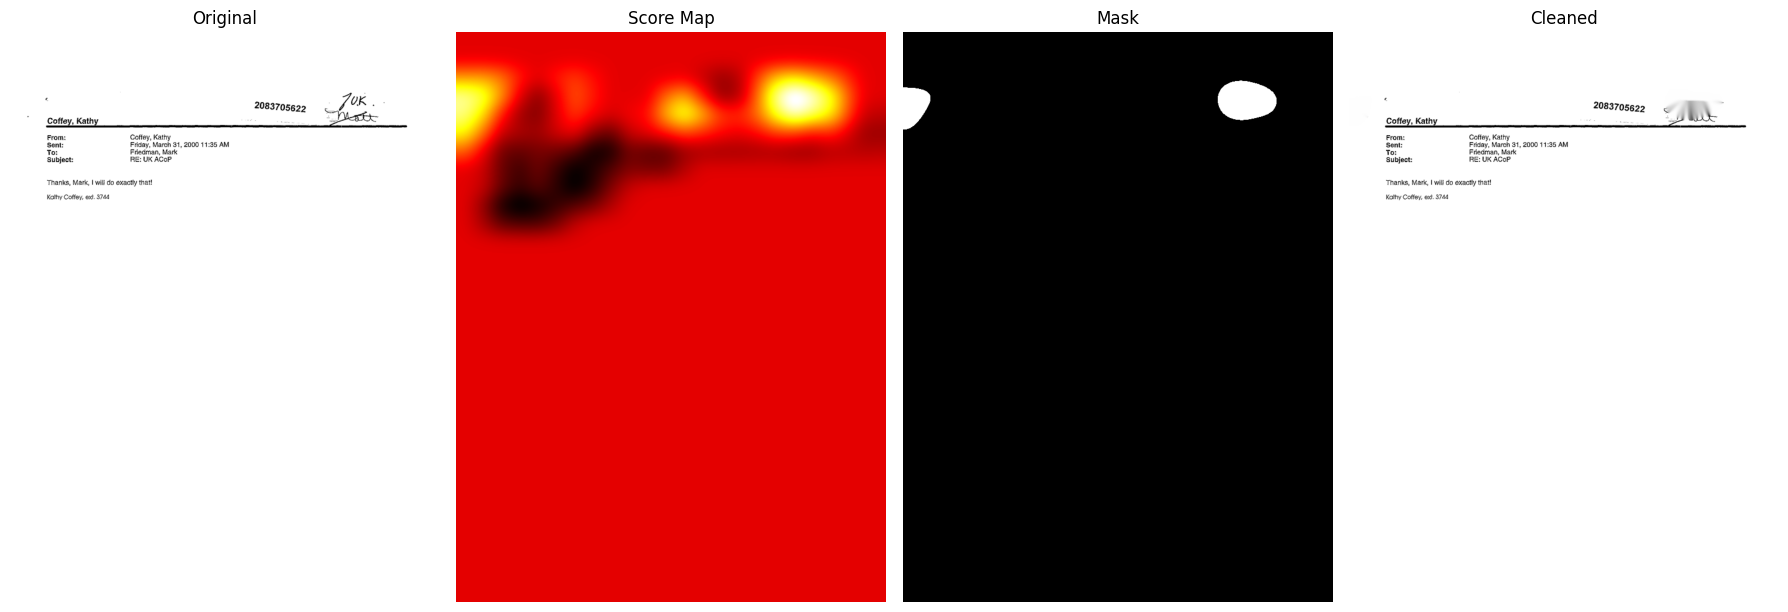

In [106]:
test_image_path = r"C:\\Users\\ziada\Downloads\big_ocr\\test\\email\\2083705622.tif"  

image = cv2.imread(test_image_path)
if image is None:
    raise FileNotFoundError(test_image_path)

model = loadHandwritingRemovalModel(HANDWRITING_MODEL_PATH)

scoreMap = predictHandwritingScoreMap(image, model)

mask = buildHandwritingMask(
    scoreMap,
    model.threshold,
)

cleaned = cv2.inpaint(
    image,
    mask,
    3,
    cv2.INPAINT_TELEA,
)

showResults(image, scoreMap, mask, cleaned)

Loaded rf: classifier=RandomForestClassifier, patchSize=64, stride=32, threshold=0.7


d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle-v2\Gazelle\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
d:\Ziad\university\GP-2\Gazelle

Loaded xgb: classifier=XGBClassifier, patchSize=64, stride=32, threshold=0.7


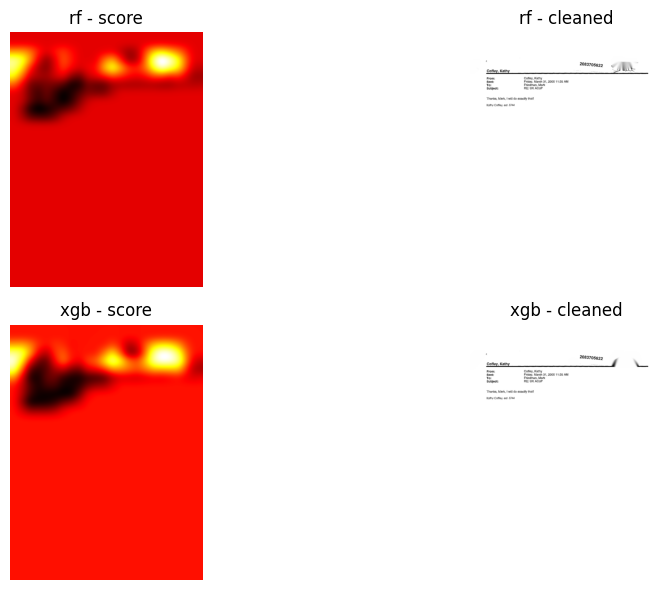

In [ ]:

test_image_path = r"C:\\Users\\ziada\Downloads\big_ocr\\test\\email\\2083705622.tif"  
image = cv2.imread(test_image_path)
if image is None:
    raise FileNotFoundError(test_image_path)

models = { 'rf': HANDWRITING_MODEL_PATH, 'xgb': HANDWRITING_MODEL_XGB_PATH }
results = {}
from pathlib import Path
for name, path in models.items():
    p = Path(path)
    if not p.exists():
        print(f"Model {name} not found at {path}")
        continue
    m = loadHandwritingRemovalModel(path)
    print(f"Loaded {name}: classifier={type(m.classifier).__name__}, patchSize={m.patchSize}, stride={m.stride}, threshold={m.threshold}")
    score = predictHandwritingScoreMap(image, m)
    mask = buildHandwritingMask(score, m.threshold)
    cleaned = cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)
    results[name] = (score, mask, cleaned)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
i = 1
for name, (score, mask, cleaned) in results.items():
    plt.subplot(2, len(results), i)
    plt.title(f"{name} - score")
    plt.imshow(score, cmap='hot')
    plt.axis('off')
    i += 1
    plt.subplot(2, len(results), i)
    plt.title(f"{name} - cleaned")
    plt.imshow(cv2.cvtColor(cleaned, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    i += 1
plt.tight_layout()